In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
import os

In [4]:
import librosa
import librosa.display

In [9]:
import matplotlib.pyplot as plt

In [11]:
!pip install --upgrade tensorflow

In [12]:
from matplotlib.pyplot import specgram

In [13]:
import glob

In [14]:
from sklearn.metrics import confusion_matrix

In [16]:
import IPython.display as ipd # to play audio in the notebook
import os
import sys
import warnings
if not sys.warnoptions:
    warnings.simplefilter('ignore')
warnings.filterwarnings('ignore', category=DeprecationWarning)


In [28]:
RAVDESS="F:/audio/data"

In [29]:
dir_list = os.listdir(RAVDESS)
dir_list.sort()
dir_list

['Actor_01',
 'Actor_02',
 'Actor_03',
 'Actor_04',
 'Actor_05',
 'Actor_06',
 'Actor_07',
 'Actor_08',
 'Actor_09',
 'Actor_10',
 'Actor_11',
 'Actor_12',
 'Actor_13',
 'Actor_14',
 'Actor_15',
 'Actor_16',
 'Actor_17',
 'Actor_18',
 'Actor_19',
 'Actor_20',
 'Actor_21',
 'Actor_22',
 'Actor_23',
 'Actor_24']

In [31]:
emotion = []
gender = []
path = []

# Loop through each directory (actor)
for i in dir_list:
    # Get the list of files in each actor's directory
    fname = os.listdir(RAVDESS + '/' + i)
    for f in fname:
        # Extract metadata from the filename
        part = f.split('.')[0].split('-')
        emotion.append(int(part[2]))  # Store emotion code
        
        # Determine gender based on the actor ID (part[6])
        temp = int(part[6])
        if temp % 2 == 0:
            temp = "female"
        else:
            temp = "male"
        gender.append(temp)  # Store gender
        
        # Store the full path to the audio file
        path.append(RAVDESS + '/' + i + '/' + f)

# Create a DataFrame for emotions and replace numeric codes with emotion labels
RAV_df = pd.DataFrame(emotion)
RAV_df = RAV_df.replace({1: 'neutral', 2: 'calm', 3: 'happy', 4: 'sad', 5: 'angry', 6: 'fear', 7: 'disgust', 8: 'surprise'})

# Concatenate the gender DataFrame with the emotion DataFrame
RAV_df = pd.concat([pd.DataFrame(gender), RAV_df], axis=1)
RAV_df.columns = ['gender', 'emotion']  # Name the columns

# Create a new 'labels' column combining gender and emotion
RAV_df['labels'] = RAV_df.gender + '_' + RAV_df.emotion

# Add a 'source' column to label all entries as 'RAVDESS'
RAV_df['source'] = 'RAVDESS'

# Add the file paths as a new column
RAV_df = pd.concat([RAV_df, pd.DataFrame(path, columns=['path'])], axis=1)

# Drop the gender and emotion columns (optional, if you only need labels and paths)
RAV_df = RAV_df.drop(['gender', 'emotion'], axis=1)

# Show the first few rows of the resulting DataFrame
RAV_df.head()


,labels,source,path
0,male_neutral,RAVDESS,F:/audio/data/Actor_01/03-01-01-01-01-01-01.wav
1,male_neutral,RAVDESS,F:/audio/data/Actor_01/03-01-01-01-01-02-01.wav
2,male_neutral,RAVDESS,F:/audio/data/Actor_01/03-01-01-01-02-01-01.wav
3,male_neutral,RAVDESS,F:/audio/data/Actor_01/03-01-01-01-02-02-01.wav
4,male_calm,RAVDESS,F:/audio/data/Actor_01/03-01-02-01-01-01-01.wav


In [32]:
RAV_df.loc[RAV_df['path'] == 'F:/audio/data/Actor_20/03-01-02-02-02-01-20.wav']


,labels,source,path
1150,female_calm,RAVDESS,F:/audio/data/Actor_20/03-01-02-02-02-01-20.wav


In [33]:
RAV_df.labels.value_counts()


labels
male_calm          96
male_happy         96
male_sad           96
male_angry         96
male_fear          96
male_disgust       96
male_surprise      96
female_calm        96
female_happy       96
female_sad         96
female_angry       96
female_fear        96
female_disgust     96
female_surprise    96
male_neutral       48
female_neutral     48
Name: count, dtype: int64

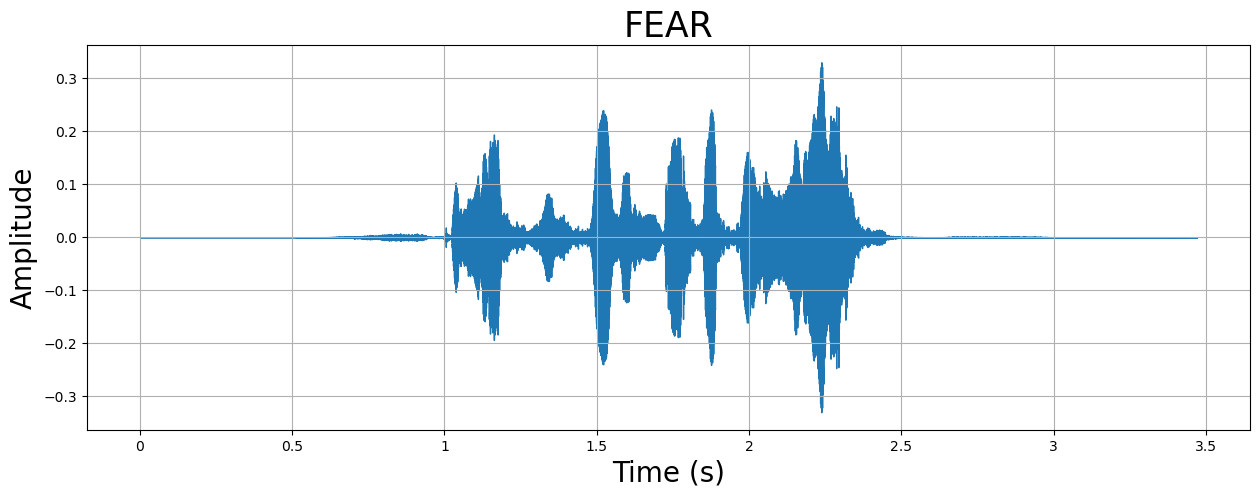

In [34]:
fname = 'F:/audio/data/Actor_14/03-01-06-02-02-02-14.wav'

# Load the audio file
data, sample_rate = librosa.load(fname)

# Plot the waveform
plt.figure(figsize=(15, 5))
librosa.display.waveshow(data, sr=sample_rate)
plt.title('FEAR', size=25)
plt.xlabel('Time (s)', size=20)
plt.ylabel('Amplitude', size=20)
plt.grid()
plt.show()

# Play the audio
ipd.Audio(fname)

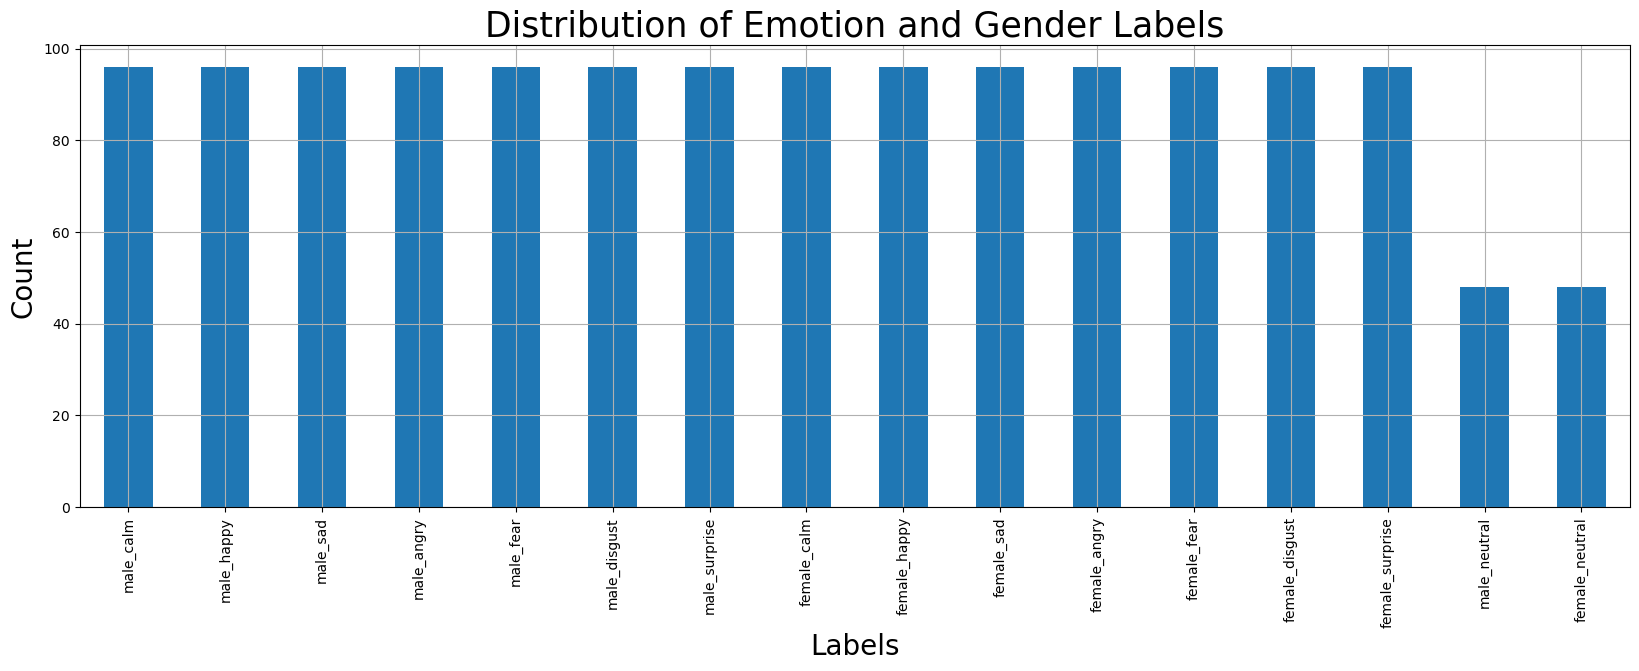

labels
male_calm          96
male_happy         96
male_sad           96
male_angry         96
male_fear          96
male_disgust       96
male_surprise      96
female_calm        96
female_happy       96
female_sad         96
female_angry       96
female_fear        96
female_disgust     96
female_surprise    96
male_neutral       48
female_neutral     48
Name: count, dtype: int64


(1440, 3)

In [35]:
df = RAV_df

# Plot the distribution of labels
plt.figure(figsize=(20, 6))
df.labels.value_counts().plot(kind='bar')
plt.title('Distribution of Emotion and Gender Labels', size=25)
plt.xlabel('Labels', size=20)
plt.ylabel('Count', size=20)
plt.grid()
plt.show()

# Print the value counts
print(df.labels.value_counts())

# Display the first few rows of the DataFrame
df.head()

# Save the DataFrame to a CSV file
df.to_csv("Data_path.csv", index=False)

# Display the shape of the DataFrame
df.shape

In [36]:
df.shape

(1440, 3)

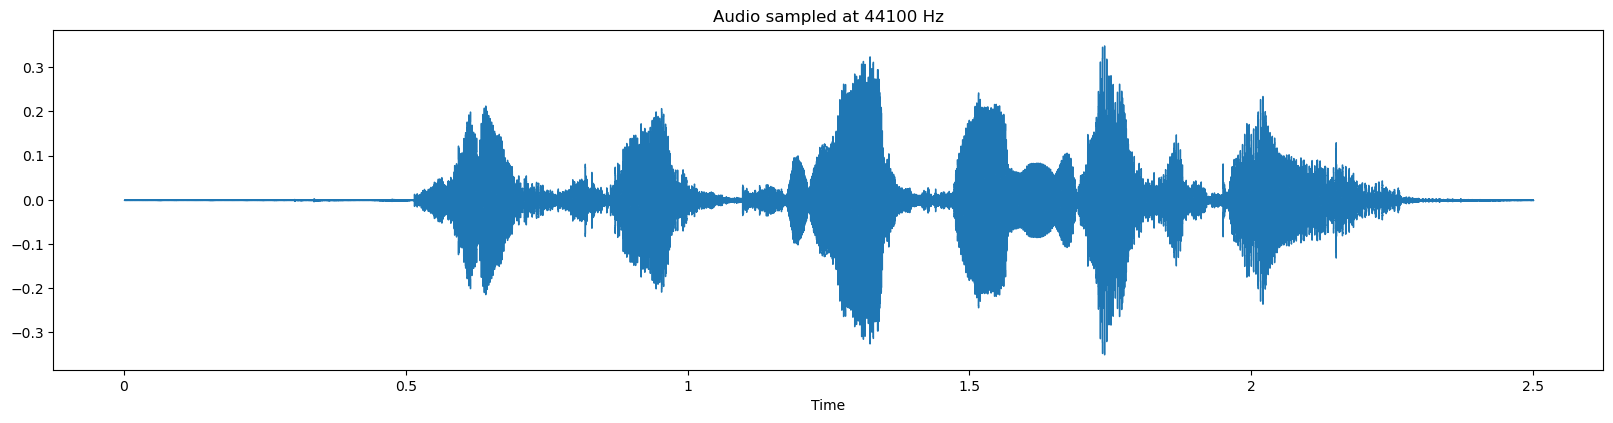

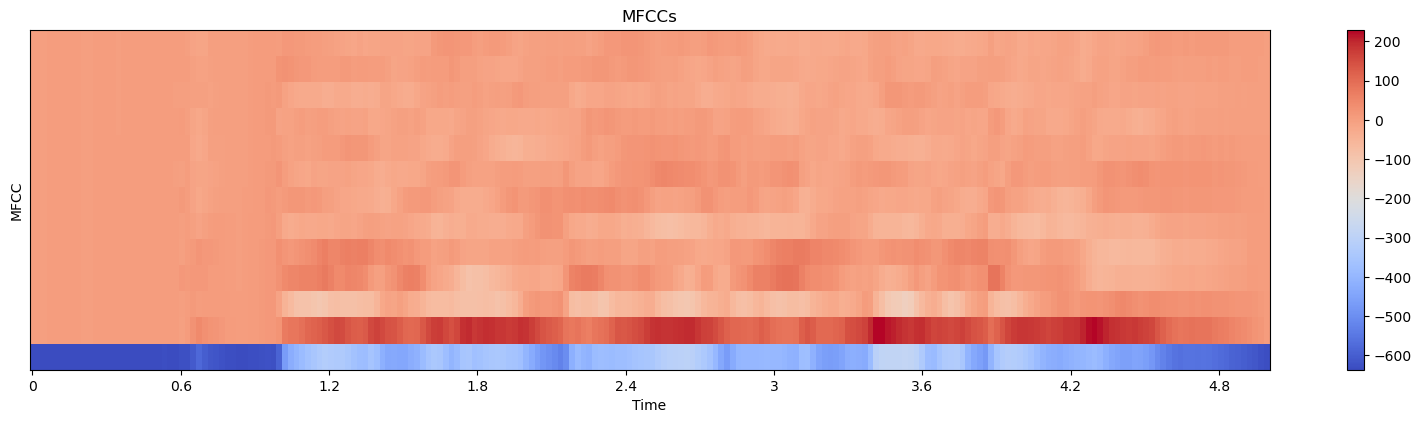

In [37]:
path = "F:/audio/data/Actor_08/03-01-05-02-01-01-08.wav"

# Load the audio file
X, sample_rate = librosa.load(path, duration=2.5, sr=22050*2, offset=0.5)

# Compute MFCCs
mfcc = librosa.feature.mfcc(y=X, sr=sample_rate, n_mfcc=13)

# Plot the audio waveform
plt.figure(figsize=(20, 15))
plt.subplot(3, 1, 1)
librosa.display.waveshow(X, sr=sample_rate)
plt.title('Audio sampled at 44100 Hz')

# Plot the MFCCs
plt.figure(figsize=(20, 15))
plt.subplot(3, 1, 1)
librosa.display.specshow(mfcc, x_axis='time')
plt.ylabel('MFCC')
plt.colorbar()
plt.title('MFCCs')

# Play the audio
ipd.Audio(path)

Length of MFCC features for female: 216
Length of MFCC features for male: 216


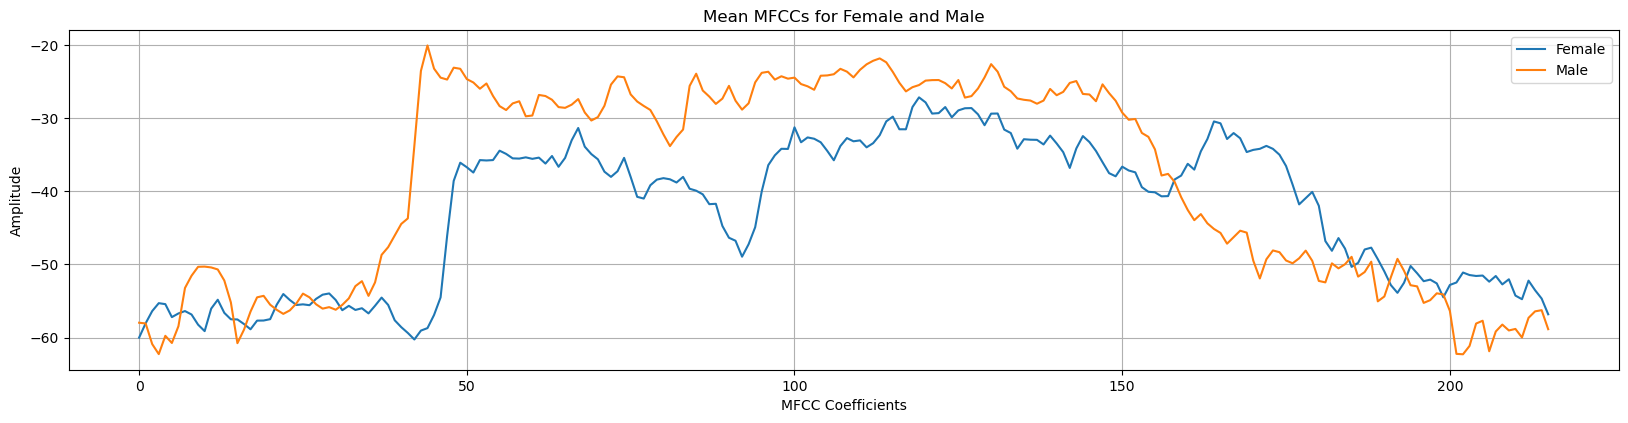

In [39]:
path_female = "F:/audio/data/Actor_12/03-01-03-01-02-01-12.wav"
X_female, sample_rate_female = librosa.load(path_female, duration=2.5, sr=22050*2, offset=0.5)  
female_mfcc = np.mean(librosa.feature.mfcc(y=X_female, sr=sample_rate_female, n_mfcc=13), axis=0)
print("Length of MFCC features for female:", len(female_mfcc))  # Print the length of MFCC features for female

# Load male audio
path_male = "F:/audio/data/Actor_11/03-01-03-01-02-02-11.wav"
X_male, sample_rate_male = librosa.load(path_male, duration=2.5, sr=22050*2, offset=0.5)  
male_mfcc = np.mean(librosa.feature.mfcc(y=X_male, sr=sample_rate_male, n_mfcc=13), axis=0)
print("Length of MFCC features for male:", len(male_mfcc))  # Print the length of MFCC features for male

# Plot the MFCCs for both genders
plt.figure(figsize=(20, 15))
plt.subplot(3, 1, 1)
plt.plot(female_mfcc, label='Female')
plt.plot(male_mfcc, label='Male')
plt.title('Mean MFCCs for Female and Male')
plt.xlabel('MFCC Coefficients')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.show()

In [41]:
!pip install keras

In [46]:
import keras
from keras.preprocessing import sequence
from tensorflow.keras.preprocessing.text import Tokenizer

In [47]:
from keras.models import Sequential, Model, model_from_json
from keras.layers import Dense, Embedding, LSTM

In [51]:
from keras.layers import Input, Flatten, Dropout, Activation, BatchNormalization
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from tensorflow.keras.utils import to_categorical
from keras.callbacks import (EarlyStopping, LearningRateScheduler,
                             ModelCheckpoint, TensorBoard, ReduceLROnPlateau)
from keras import losses, models, optimizers
from keras.activations import relu, softmax
from keras.layers import (Convolution2D, GlobalAveragePooling2D, BatchNormalization, Flatten, Dropout,
                          GlobalMaxPool2D, MaxPool2D, concatenate, Activation, Input, Dense)
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


In [52]:
from tqdm import tqdm, tqdm_pandas
import scipy
from scipy.stats import skew
import json

In [53]:
# Function to augment audio data (example placeholder)
def speedNpitch(data):
    # This function should implement your audio augmentation logic
    return data  # Replace with actual augmentation logic

# Parameters
sampling_rate = 44100  # Set your desired sampling rate
audio_duration = 2.5    # Duration of audio clip
n_mfcc = 13             # Number of MFCC features to extract
n_melspec = 128         # Number of Mel bands to use for mel spectrogram

# Extracting the MFCC feature as an image (Matrix format).
def prepare_data(df, n, aug, mfcc):
    X = np.empty(shape=(df.shape[0], n, 216, 1))  # Change dimensions as needed
    input_length = sampling_rate * audio_duration
    
    cnt = 0
    for fname in tqdm(df.path):
        file_path = fname
        # Load audio file
        data, _ = librosa.load(file_path, sr=sampling_rate, duration=audio_duration, offset=0.5)

        # Random offset / Padding
        if len(data) > input_length:
            max_offset = len(data) - input_length
            offset = np.random.randint(max_offset)
            data = data[offset:(input_length + offset)]
        else:
            if input_length > len(data):
                max_offset = input_length - len(data)
                offset = np.random.randint(max_offset)
            else:
                offset = 0
            data = np.pad(data, (offset, int(input_length) - len(data) - offset), "constant")

        # Augmentation? 
        if aug == 1:
            data = speedNpitch(data)
        
        # which feature?
        if mfcc == 1:
            # MFCC extraction 
            MFCC = librosa.feature.mfcc(y=data, sr=sampling_rate, n_mfcc=n_mfcc)
            MFCC = np.expand_dims(MFCC, axis=-1)
            X[cnt,] = MFCC
        else:
            # Log-melspectrogram
            melspec = librosa.feature.melspectrogram(data, n_mels=n_melspec)
            logspec = librosa.amplitude_to_db(melspec)
            logspec = np.expand_dims(logspec, axis=-1)
            X[cnt,] = logspec
            
        cnt += 1
    
    return X

# Usage
# Assuming df is your DataFrame containing audio paths and is already defined
# Prepare the data
X_data = prepare_data(df, n=13, aug=0, mfcc=1)

100%|██████████| 1440/1440 [00:47<00:00, 30.56it/s]


In [59]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

In [61]:

# Assuming RAV_df is your DataFrame containing audio paths and labels
# X contains the MFCC features and RAV_df.labels contains the target labels
X = prepare_data(RAV_df, n=n_mfcc, aug=0, mfcc=1)  # Replace with your feature extraction logic
y = RAV_df['labels']  # Assuming labels are stored in the 'labels' column of RAV_df

# Split between train and test 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=True, random_state=42)

# One hot encode the target 
lb = LabelEncoder()
y_train = to_categorical(lb.fit_transform(y_train))
y_test = to_categorical(lb.transform(y_test))  # Use transform to maintain consistent encoding

# Normalization as per the standard NN process
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# Build CNN model
def get_2d_conv_model(n):
    model = Sequential()
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(n, 216, 1)))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(y_train.shape[1], activation='softmax'))  # Output layer with softmax for multi-class
    return model

# Initialize the model
model = get_2d_conv_model(n=n_mfcc)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model_history = model.fit(X_train, y_train, validation_data=(X_test, y_test), 
                          batch_size=16, verbose=2, epochs=50)

100%|██████████| 1440/1440 [00:36<00:00, 39.54it/s]


Epoch 1/50
68/68 - 6s - 82ms/step - accuracy: 0.1167 - loss: 2.6504 - val_accuracy: 0.2222 - val_loss: 2.3873
Epoch 2/50
68/68 - 1s - 18ms/step - accuracy: 0.2361 - loss: 2.2760 - val_accuracy: 0.3111 - val_loss: 2.0216
Epoch 3/50
68/68 - 1s - 18ms/step - accuracy: 0.3296 - loss: 1.9630 - val_accuracy: 0.3750 - val_loss: 1.7442
Epoch 4/50
68/68 - 1s - 18ms/step - accuracy: 0.4176 - loss: 1.6870 - val_accuracy: 0.4278 - val_loss: 1.6536
Epoch 5/50
68/68 - 1s - 19ms/step - accuracy: 0.4991 - loss: 1.4548 - val_accuracy: 0.4389 - val_loss: 1.5906
Epoch 6/50
68/68 - 1s - 22ms/step - accuracy: 0.5583 - loss: 1.2856 - val_accuracy: 0.4750 - val_loss: 1.4172
Epoch 7/50
68/68 - 1s - 21ms/step - accuracy: 0.6278 - loss: 1.0868 - val_accuracy: 0.5361 - val_loss: 1.3505
Epoch 8/50
68/68 - 1s - 22ms/step - accuracy: 0.6759 - loss: 0.9750 - val_accuracy: 0.5417 - val_loss: 1.3631
Epoch 9/50
68/68 - 2s - 23ms/step - accuracy: 0.7102 - loss: 0.8301 - val_accuracy: 0.5361 - val_loss: 1.3288
Epoch 10/5

In [62]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import optimizers
from tensorflow.keras.models import load_model


In [63]:
def print_confusion_matrix(confusion_matrix, class_names, figsize=(10, 7), fontsize=14):
    df_cm = pd.DataFrame(confusion_matrix, index=class_names, columns=class_names)
    fig = plt.figure(figsize=figsize)
    try:
        heatmap = sns.heatmap(df_cm, annot=True, fmt="d")
    except ValueError:
        raise ValueError("Confusion matrix values must be integers.")

    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right', fontsize=fontsize)
    heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right', fontsize=fontsize)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

In [64]:
def save_model(filename, model):
    """
    Saves the trained model in .h5 format as well as its json version
    """
    # Save model and weights
    model_name = filename + '.h5'
    save_dir = os.path.join(os.getcwd(), 'saved_models')

    if not os.path.isdir(save_dir):
        os.makedirs(save_dir)
    model_path = os.path.join(save_dir, model_name)
    model.save(model_path)
    print('Model and weights saved at %s' % model_path)

    # Save the model to disk in json format
    model_json = model.to_json()
    with open(filename + ".json", "w") as json_file:
        json_file.write(model_json)
    print("Model architecture saved to disk.")

In [65]:
class GetResults:
    
    def __init__(self, model_history, model, X_test, y_test, labels):
        self.model_history = model_history
        self.model = model
        self.X_test = X_test
        self.y_test = y_test             
        self.labels = labels

    def create_plot(self):
        '''Check the log loss of both train and validation'''
        plt.plot(self.model_history.history['loss'])
        plt.plot(self.model_history.history['val_loss'])
        plt.title('Model Loss')
        plt.ylabel('Loss')
        plt.xlabel('Epoch')
        plt.legend(['Train', 'Validation'], loc='upper left')
        plt.show()

    def create_results(self):
        '''Predict on test set and get accuracy results'''
        opt = optimizers.Adam(0.001)
        self.model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
        score = self.model.evaluate(self.X_test, self.y_test, verbose=0)
        print("%s: %.2f%%" % (self.model.metrics_names[1], score[1] * 100))

    def confusion_results(self):
        '''Plot confusion matrix results'''
        preds = self.model.predict(self.X_test, batch_size=16, verbose=2)
        preds = preds.argmax(axis=1)
        preds = preds.astype(int).flatten()
        preds = (lb.inverse_transform((preds)))

        actual = self.y_test.argmax(axis=1)
        actual = actual.astype(int).flatten()
        actual = (lb.inverse_transform((actual)))

        classes = self.labels
        classes.sort()    

        c = confusion_matrix(actual, preds)
        print_confusion_matrix(c, class_names=classes)
    
    def accuracy_results_gender(self):
        '''Print out the accuracy score and confusion matrix heat map for gender classification'''
        preds = self.model.predict(self.X_test, batch_size=16, verbose=2)
        preds = preds.argmax(axis=1)
        preds = preds.astype(int).flatten()
        preds = (lb.inverse_transform((preds)))

        actual = self.y_test.argmax(axis=1)
        actual = actual.astype(int).flatten()
        actual = (lb.inverse_transform((actual)))
        
        # Convert predictions to DataFrame and map genders
        actual_df = pd.DataFrame(actual)
        preds_df = pd.DataFrame(preds)

        actual_df.replace({'female_.*': 'female', 'male_.*': 'male'}, regex=True, inplace=True)
        preds_df.replace({'female_.*': 'female', 'male_.*': 'male'}, regex=True, inplace=True)

        classes = actual_df.loc[:, 0].unique() 
        classes.sort()    

        c = confusion_matrix(actual_df, preds_df)
        print(accuracy_score(actual_df, preds_df))
        print_confusion_matrix(c, class_names=classes)

In [68]:
def _save_model_(filename):
    """
    Saves the trained model in .h5 format and also saves its JSON version.
    """
    # Save model and weights
    model_name = filename + '.h5'
    save_dir = os.path.join(os.getcwd(), 'saved_models')

    if not os.path.isdir(save_dir):
        os.makedirs(save_dir)

    model_path = os.path.join(save_dir, model_name)
    model.save(model_path)
    print('Model and weights saved at %s' % model_path)

    # Save the model architecture to disk
    model_json = model.to_json()
    with open(filename + ".json", "w") as json_file:
        json_file.write(model_json)
    print("Model architecture saved to %s.json" % filename)
_save_model_('mfcc_model')


Model and weights saved at C:\Users\HP\Downloads\saved_models\mfcc_model.h5
Model architecture saved to mfcc_model.json


In [70]:
RAV_df.labels.unique()


array(['male_neutral', 'male_calm', 'male_happy', 'male_sad',
       'male_angry', 'male_fear', 'male_disgust', 'male_surprise',
       'female_neutral', 'female_calm', 'female_happy', 'female_sad',
       'female_angry', 'female_fear', 'female_disgust', 'female_surprise'],
      dtype=object)

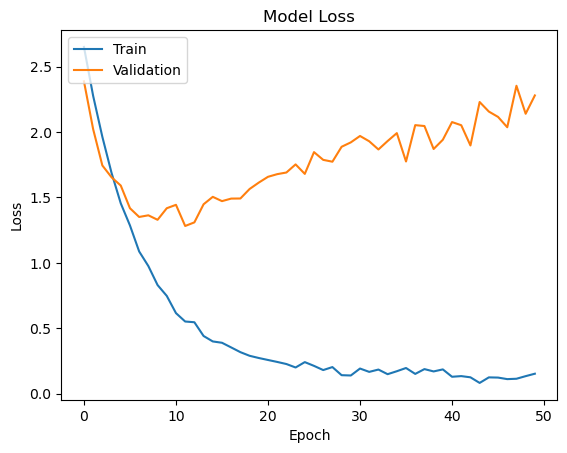

compile_metrics: 55.00%
23/23 - 0s - 12ms/step


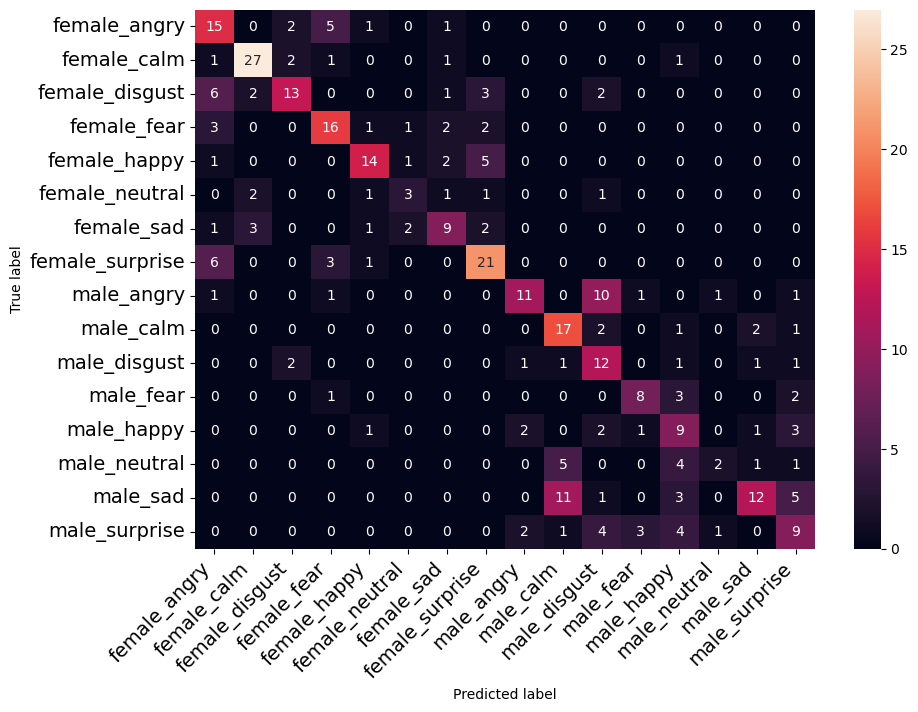

In [74]:
# Use RAV_df to get the unique labels
results = GetResults(model_history, model, X_test, y_test, RAV_df['labels'].unique())

# Plot loss
results.create_plot()

# Show accuracy results
results.create_results()

# Plot confusion matrix
results.confusion_results()



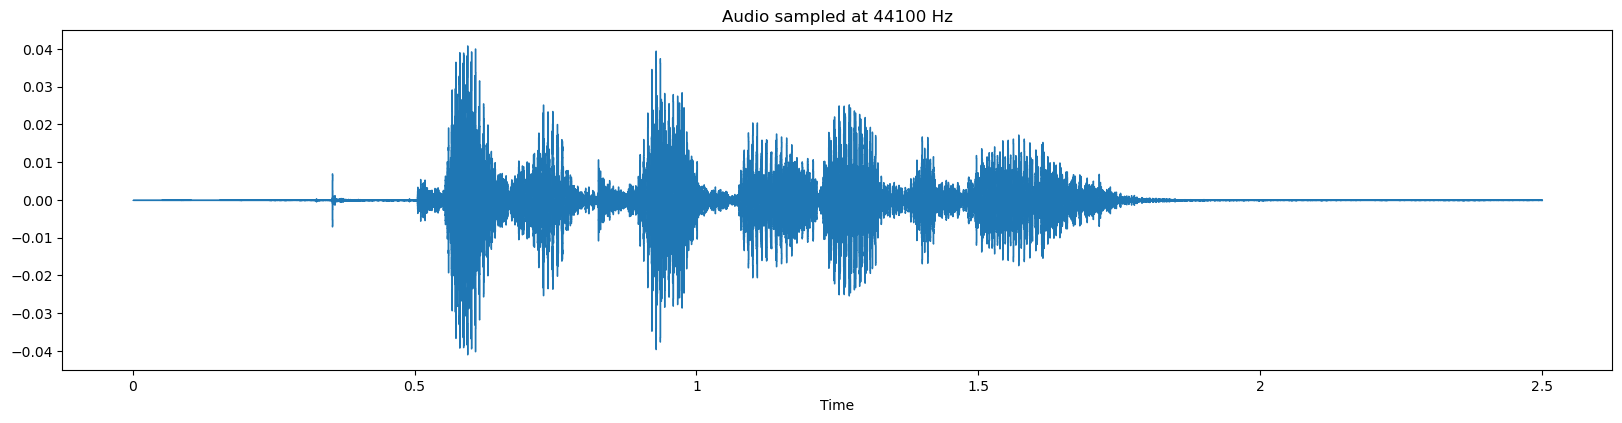

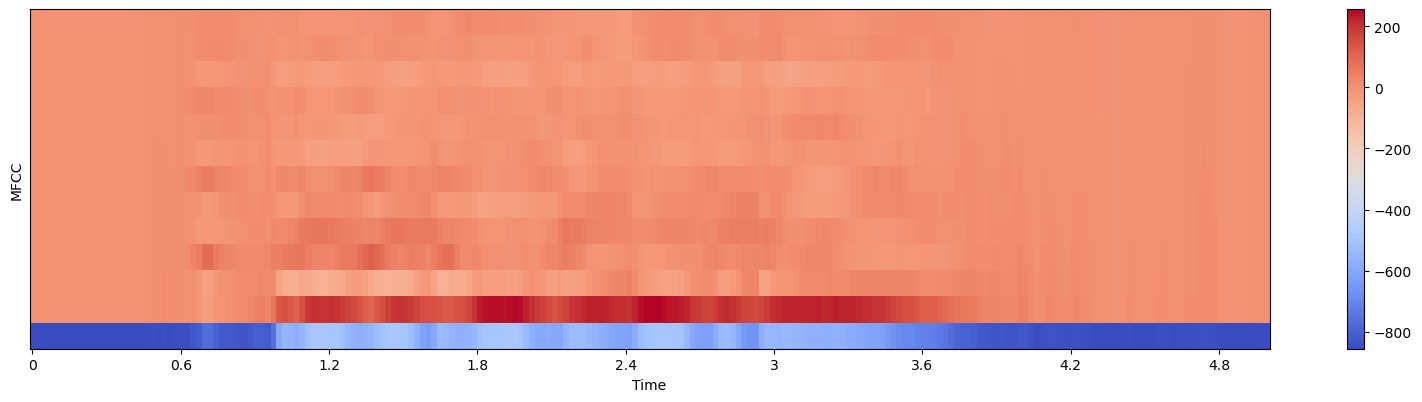

In [75]:
# Updated path based on your dataset location
path = 'F:/audio/data/Actor_01/03-01-01-01-01-01-01.wav'

# Load the audio file with librosa
X, sample_rate = librosa.load(path, duration=2.5, sr=22050*2, offset=0.5)

# Extract MFCC features
mfcc = librosa.feature.mfcc(y=X, sr=sample_rate, n_mfcc=13)

# Plot the audio wave
plt.figure(figsize=(20, 15))
plt.subplot(3, 1, 1)
librosa.display.waveshow(X, sr=sample_rate)
plt.title('Audio sampled at 44100 Hz')

# Plot MFCC
plt.figure(figsize=(20, 15))
plt.subplot(3, 1, 1)
librosa.display.specshow(mfcc, x_axis='time')
plt.ylabel('MFCC')
plt.colorbar()

# Play the audio
ipd.Audio(path)


In [76]:
# Define model name and save directory
model_name = 'mfcc_model.h5'
save_dir = os.path.join(os.getcwd(), 'saved_models')

# Create directory if it doesn't exist
if not os.path.isdir(save_dir):
    os.makedirs(save_dir)

# Define the model save path
model_path = os.path.join(save_dir, model_name)

# Save the model and weights in .h5 format
model.save(model_path)
print(f'Model and weights saved at {model_path}')

# Save the model architecture in a JSON file
model_json = model.to_json()
with open(os.path.join(save_dir, "model_json_aug.json"), "w") as json_file:
    json_file.write(model_json)
print("Model architecture saved as JSON")


Model and weights saved at C:\Users\HP\Downloads\saved_models\mfcc_model.h5
Model architecture saved as JSON


In [78]:
# Import necessary libraries
from tensorflow.keras.models import model_from_json
import tensorflow as tf
# Load model architecture from the JSON file
json_file = open('saved_models/model_json_aug.json', 'r')  # Path corrected to where you saved the JSON
loaded_model_json = json_file.read()
json_file.close()

# Load the model from the JSON structure
loaded_model = model_from_json(loaded_model_json)

# Load weights into the loaded model
loaded_model.load_weights("saved_models/mfcc_model.h5")  # Ensure path to the .h5 file is correct
print("Loaded model from disk")

# Compile the loaded model with RMSprop optimizer
opt = tf.keras.optimizers.RMSprop(learning_rate=0.00001)
loaded_model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

# Evaluate the model on the test set
score = loaded_model.evaluate(X_test, y_test, verbose=0)
print("Accuracy: %.2f%%" % (score[1] * 100))


Loaded model from disk
Accuracy: 55.00%


In [79]:
# Use the loaded model to predict classes for the test set
preds = loaded_model.predict(X_test, batch_size=16, verbose=1)

# Get the predicted class labels by finding the index of the maximum value for each prediction
preds = preds.argmax(axis=1)

# Display the predicted class labels
preds


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


array([10,  9,  1,  1,  8, 14,  2,  3,  3,  9,  2,  7,  9,  0, 14,  0,  0,
       11,  1,  2,  7,  5,  1,  9,  7, 14, 11, 15,  2, 10, 10,  8, 11, 12,
        9,  9,  2,  8,  4,  8,  1, 12,  1,  8, 12,  9,  1, 13,  3,  6, 10,
        3, 12,  3,  6,  3,  1,  7, 12, 12, 13,  6, 15,  4,  3,  7,  1, 10,
        7, 15,  7,  7,  1,  4, 10,  9,  8,  7,  9,  2, 12,  4,  0,  9,  7,
        8,  3,  1, 10,  6,  5,  1,  6,  4,  5, 10, 15, 12,  7,  8,  7, 11,
       11, 15, 15,  7,  5,  2, 15,  9,  7,  0,  3,  9, 10,  0,  3, 10, 10,
       11,  0,  1,  0, 11, 14, 10,  7, 15,  3,  3, 12, 12,  9, 11,  4, 14,
        1, 10,  2,  2, 10,  2,  4, 15,  3, 12,  0, 15, 15,  3, 11,  6,  1,
       12,  4, 15,  5, 14, 15,  3,  9, 10,  0,  6,  4,  7, 10,  0,  7,  7,
        1, 12,  3,  2, 11,  1, 10, 15, 15,  0,  7,  3,  4,  5,  1,  9,  7,
        3,  0, 15, 14,  3,  5,  1, 12,  7, 15,  7,  0,  1,  0,  9, 15,  6,
        9,  0, 10,  7, 12, 12,  6, 10,  7,  3, 10, 11,  0,  3,  7,  8,  4,
       10,  1,  3, 14,  2

In [80]:
preds = preds.astype(int).flatten()
preds = (lb.inverse_transform((preds)))
preds = pd.DataFrame({'predictedvalues': preds})
actual = y_test.argmax(axis=1)
actual = actual.astype(int).flatten()
actual = (lb.inverse_transform((actual)))
actual = pd.DataFrame({'actualvalues': actual})
finaldf = actual.join(preds)
finaldf[170:180]


,actualvalues,predictedvalues
170,female_calm,female_calm
171,male_fear,male_happy
172,female_angry,female_fear
173,female_disgust,female_disgust
174,male_fear,male_fear
175,female_calm,female_calm
176,male_angry,male_disgust
177,male_surprise,male_surprise
178,male_happy,male_surprise
179,female_sad,female_angry


In [81]:
finaldf.to_csv('Predictions.csv', index=False)
finaldf.groupby('predictedvalues').count()


,actualvalues
predictedvalues,
female_angry,34
female_calm,34
female_disgust,19
female_fear,27
female_happy,20
female_neutral,7
female_sad,17
female_surprise,34
male_angry,16


In [82]:
modidf = pd.read_csv("Predictions.csv")
modidf['actualvalues'] = modidf.actualvalues.replace({
    'female_angry': 'angry',
    'female_disgust': 'disgust',
    'female_fear': 'fear',
    'female_calm': 'calm',
    'female_happy': 'happy',
    'female_sad': 'sad',
    'female_surprise': 'surprise',
    'female_neutral': 'neutral',
    'male_angry': 'angry',
    'male_fear': 'fear',
    'male_calm': 'calm',
    'male_happy': 'happy',
    'male_sad': 'sad',
    'male_surprise': 'surprise',
    'male_neutral': 'neutral',
    'male_disgust': 'disgust'
})
modidf['predictedvalues'] = modidf.predictedvalues.replace({
    'female_angry': 'angry',
    'female_disgust': 'disgust',
    'female_fear': 'fear',
    'female_calm': 'calm',
    'female_happy': 'happy',
    'female_sad': 'sad',
    'female_surprise': 'surprise',
    'female_neutral': 'neutral',
    'male_angry': 'angry',
    'male_fear': 'fear',
    'male_calm': 'calm',
    'male_happy': 'happy',
    'male_sad': 'sad',
    'male_surprise': 'surprise',
    'male_neutral': 'neutral',
    'male_disgust': 'disgust'
})



0.5694444444444444


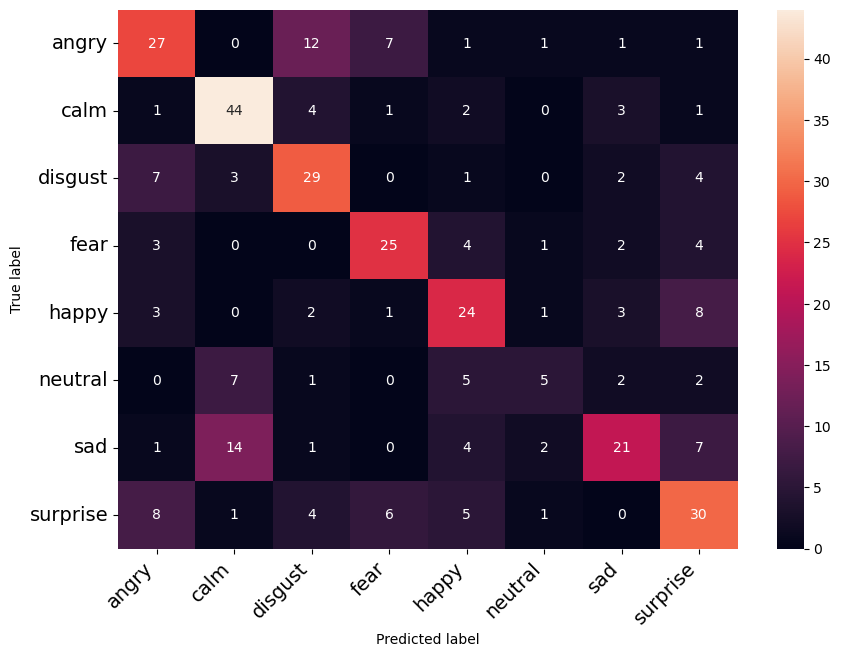

In [83]:
classes = modidf.actualvalues.unique() 
classes.sort()
c = confusion_matrix(modidf.actualvalues, modidf.predictedvalues)
print(accuracy_score(modidf.actualvalues, modidf.predictedvalues))
print_confusion_matrix(c, class_names=classes)


In [84]:
classes = modidf.actualvalues.unique()
classes.sort()
print(classification_report(modidf.actualvalues, modidf.predictedvalues, target_names=classes))


              precision    recall  f1-score   support

       angry       0.54      0.54      0.54        50
        calm       0.64      0.79      0.70        56
     disgust       0.55      0.63      0.59        46
        fear       0.62      0.64      0.63        39
       happy       0.52      0.57      0.55        42
     neutral       0.45      0.23      0.30        22
         sad       0.62      0.42      0.50        50
    surprise       0.53      0.55      0.54        55

    accuracy                           0.57       360
   macro avg       0.56      0.55      0.54       360
weighted avg       0.57      0.57      0.56       360



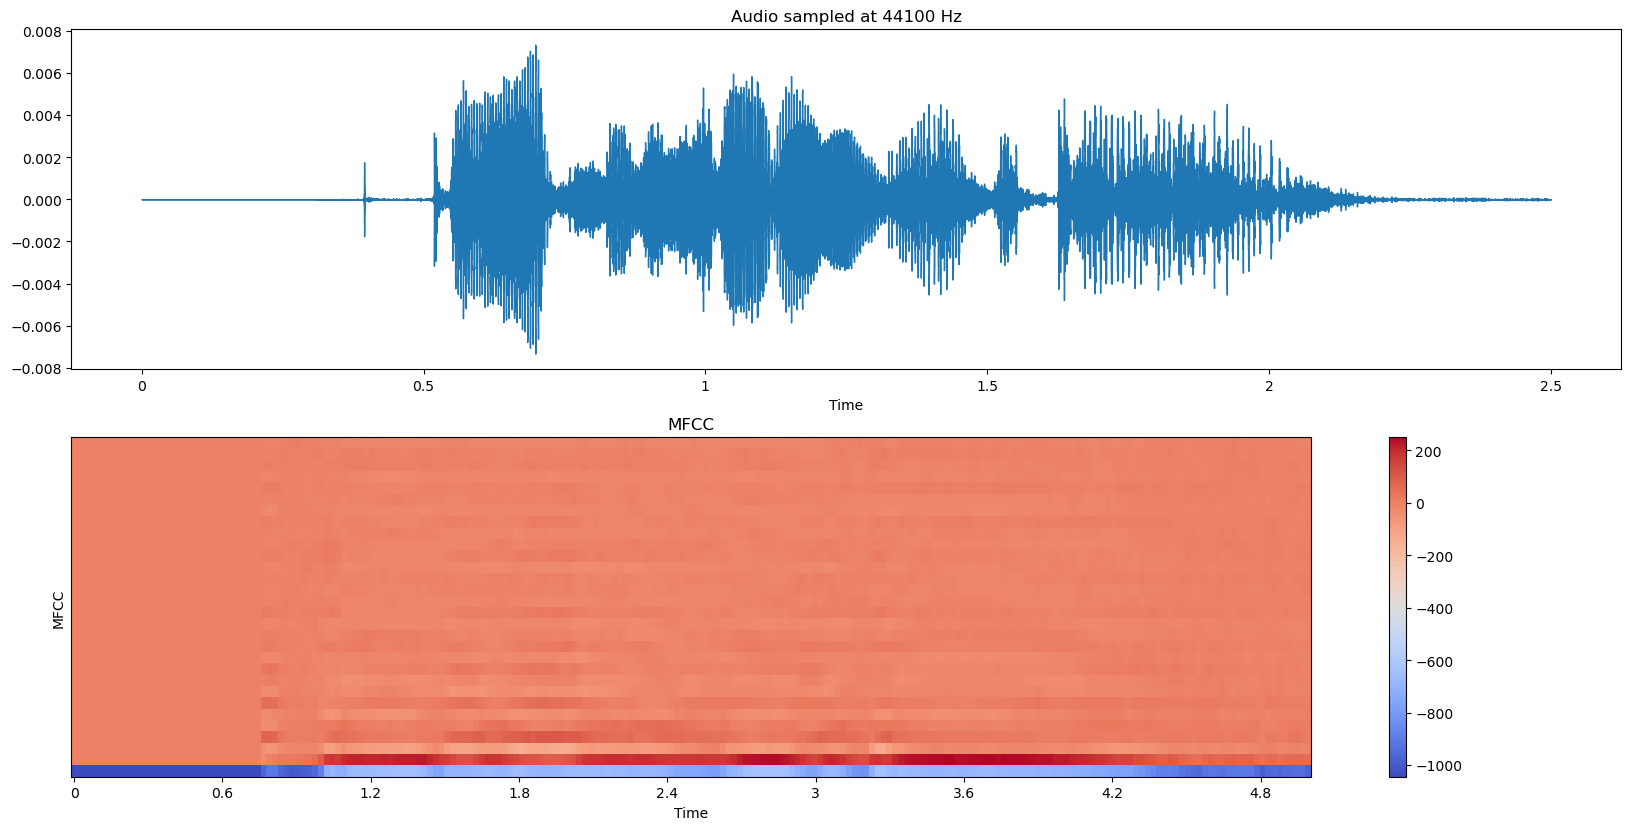

In [87]:
def prepare_data1(fname, n, aug, mfcc):
    # Load audio data
    data, _ = librosa.load(fname, sr=sampling_rate, duration=audio_duration, offset=0.5)
    
    # Define input length
    input_length = int(sampling_rate * audio_duration)  # Ensure it's an integer

    # Random offset / Padding
    if len(data) > input_length:
        max_offset = len(data) - input_length
        offset = np.random.randint(max_offset)
        data = data[offset:(input_length + offset)]
    else:
        if input_length > len(data):
            max_offset = input_length - len(data)
            offset = np.random.randint(max_offset)
            # Ensure that padding values are integers
            data = np.pad(data, (offset, int(input_length - len(data) - offset)), "constant")
        else:
            offset = 0
            data = np.pad(data, (offset, int(input_length - len(data) - offset)), "constant")
    
    if mfcc == 1:
        # MFCC extraction 
        MFCC = librosa.feature.mfcc(y=data, sr=sampling_rate, n_mfcc=n)
        MFCC = np.expand_dims(MFCC, axis=-1)
        return MFCC

# Set parameters
sampling_rate = 44100
audio_duration = 2.5
n_mfcc = 30

# Specify the path to the audio file
path = 'F:/audio/data/Actor_20/03-01-02-02-02-01-20.wav'

# Get MFCC features
mfcc = prepare_data1(path, n=n_mfcc, aug=0, mfcc=1)

# Plot audio waveform
plt.figure(figsize=(20, 15))
plt.subplot(3, 1, 1)
X, _ = librosa.load(path, sr=sampling_rate, duration=2.5, offset=0.5)
librosa.display.waveshow(X, sr=sampling_rate)
plt.title('Audio sampled at 44100 Hz')

# Plot MFCC
plt.subplot(3, 1, 2)
librosa.display.specshow(mfcc.squeeze(), x_axis='time')
plt.ylabel('MFCC')
plt.colorbar()
plt.title('MFCC')

# Display audio player
ipd.Audio(path)

In [93]:
# Make predictions
path = 'F:/audio/data/Actor_20/03-01-02-02-02-01-20.wav'

# Prepare the MFCC features
mfcc = prepare_data1(path, n=n_mfcc, aug=0, mfcc=1)

# Reshape the MFCC for prediction
mfcc = mfcc.reshape(1, mfcc.shape[0], mfcc.shape[1], 1)

In [97]:
preds = loaded_model.predict(mfcc, 
                         batch_size=16, 
                         verbose=2)

ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "dense" is incompatible with the layer: expected axis -1 of input shape to have value 3328, but received input with shape (1, 19968)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(1, 30, 216, 1), dtype=float32)
  • training=False
  • mask=None